# What are the most demanded skills for the top 3 most popular data roles in New York?

In [10]:
# Importing Libraries & Loading Data
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [11]:
df_NY = df[df['search_location'] == 'New York, United States']

In [12]:
df_skills = df_NY.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
9,Data Scientist II,sql
9,Data Scientist II,python
9,Data Scientist II,r
9,Data Scientist II,mongodb
9,Data Scientist II,mongodb
...,...,...
785546,Senior Semantic Data Engineer,python
785546,Senior Semantic Data Engineer,sql
785546,Senior Semantic Data Engineer,spark
785626,Data Acquisition Associate,microsoft teams


## Skills per Job Title

In [ ]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
# df_skills_count

,job_skills,job_title_short,skill_count
952,python,Data Scientist,9426
1210,sql,Data Analyst,9026
345,excel,Data Analyst,7776
1212,sql,Data Scientist,6341
983,r,Data Scientist,5789
...,...,...,...
802,nuix,Senior Data Scientist,1
1323,theano,Machine Learning Engineer,1
376,flask,Business Analyst,1
375,firestore,Senior Data Engineer,1


## Top 3 List

In [14]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

## Plot Count with Percent

In [15]:
# Use original df to get the count of job titles
df_job_title_count = df_NY['job_title_short'].value_counts().reset_index(name='jobs_total')

#df_job_title_count

In [16]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

#df_skills_perc

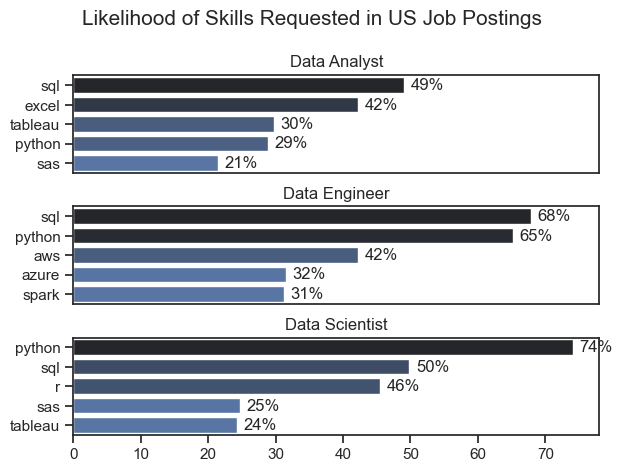

In [17]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()